Notebook for exploring the final dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
plt.style.use('default')

In [ ]:
output_dir = Path('/data/vision/polina/users/marcusbl/bin_class/thesis_figs')

Keep all slices that have a final label or is an edge slice

In [ ]:
df = pd.read_csv('/data/vision/polina/users/marcusbl/bin_class/label_sessions_data/label_session_3-11/final.csv', index_col = 0)
df = df[~df['label_3'].isna() | df['is_edge']]
df.columns

Index(['slice_num', 'stack_slices_cnt', 'full_stack_slices_cnt',
       'stack_slices', 'path', 'Brain Type', 'person', 'dataset', 'mask_path',
       'MAP ID', 'GA', 'person_id', 'label_R', 'label_1', 'is_edge', 'label_2',
       'labels_agree', 'req_relabel', 'tie_broken', 'label_3', 'final_label'],
      dtype='object')

In [ ]:
df['label_3'].value_counts() / 6970

label_3
0.0    0.829412
1.0    0.170588
Name: count, dtype: float64

In [ ]:
df['is_edge'].value_counts()

is_edge
False    6970
True     1426
Name: count, dtype: int64

In [ ]:
df[['path', 'person_id']].nunique()

path         287
person_id     98
dtype: int64

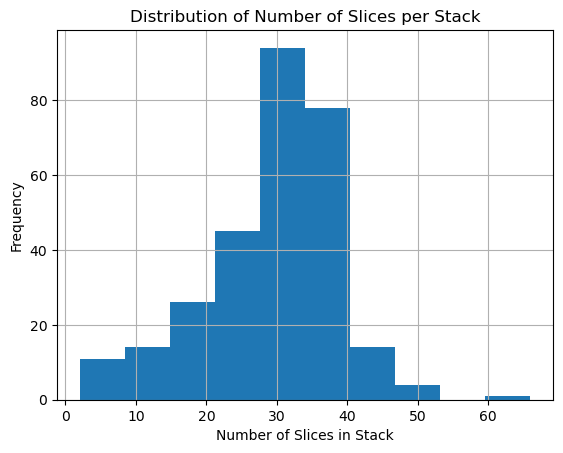

In [ ]:
df.groupby(by='path').size().hist()
plt.style.use('default')

plt.title('Distribution of Number of Slices per Stack')
plt.ylabel('Frequency')
plt.xlabel('Number of Slices in Stack')

plt.savefig(output_dir / 'slices_per_stack.png')

In [ ]:
df.groupby(by='path').size().describe()


count    287.000000
mean      29.254355
std        9.367484
min        2.000000
25%       25.000000
50%       31.000000
75%       35.000000
max       66.000000
dtype: float64

In [ ]:
df['Brain Type'].value_counts(dropna=True) / df['Brain Type'].value_counts(dropna=True).sum()

Brain Type
cor    0.358608
sag    0.352051
axi    0.289341
Name: count, dtype: float64

# Exploring the Two Datasets Separately

In [ ]:
dataset_types = ['BCH', 'R']

In [ ]:
def get_info_for(dataset_type: str):
    df_filter = df['dataset'] == dataset_type
    df_sub = df[df_filter]
    
    print(dataset_type)
    print("# of patients, ", df_sub['person'].nunique())

for dataset_type in dataset_types:
    get_info_for(dataset_type)

BCH
# of patients,  68
R
# of patients,  30


In [ ]:
df['label_1'].value_counts(dropna=False)

label_1
NaN       4440
[0]       2628
[1]        835
[0, 0]     287
[1, 1]     100
[1, 0]      68
[0, 1]      25
[2]          7
[2, 0]       4
[2, 1]       1
[0, 2]       1
Name: count, dtype: int64

In [ ]:
old_df = pd.read_csv('/data/vision/polina/users/marcusbl/bin_class/label_sessions_data/label_session_3-11/labeled_slice_df.csv', index_col = 0)

In [ ]:
old_df['label_R'].value_counts()

label_R
0.0    6035
1.0    1726
Name: count, dtype: int64

In [ ]:
df['label_1'].value_counts()

label_1
[0]       2628
[1]        835
[0, 0]     287
[1, 1]     100
[1, 0]      68
[0, 1]      25
[2]          7
[2, 0]       4
[2, 1]       1
[0, 2]       1
Name: count, dtype: int64

In [ ]:
df['label_1'].value_counts(dropna=False)

label_1
NaN       4440
[0]       2628
[1]        835
[0, 0]     287
[1, 1]     100
[1, 0]      68
[0, 1]      25
[2]          7
[2, 0]       4
[2, 1]       1
[0, 2]       1
Name: count, dtype: int64